In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('https://gist.githubusercontent.com/curran/4b59d1046d9e66f2787780ad51a1cd87/raw/9ec906b78a98cf300947a37b56cfe70d01183200/data.tsv', sep='\t')
data.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [3]:
from scipy.stats import multivariate_normal as mvn


In [4]:
# Extract the 2D data (eruptions and waiting).
X = data[['eruptions', 'waiting']].to_numpy()

# Let's create two initial mean vectors.
# For a simple approach, we can start with quartiles (like you did for 1D),
# but now for each dimension separately:
mu1_hat = np.array([
    np.percentile(X[:, 0], 25),  # Q1 of eruptions
    np.percentile(X[:, 1], 25)   # Q1 of waiting
])

mu2_hat = np.array([
    np.percentile(X[:, 0], 75),  # Q3 of eruptions
    np.percentile(X[:, 1], 75)   # Q3 of waiting
])

# Initialize two covariance matrices as identity (2x2) for simplicity.
Sigma1_hat = np.eye(2)
Sigma2_hat = np.eye(2)

# Mixing proportions (still scalars).
pi1_hat = 0.5
pi2_hat = 0.5

In [5]:
px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(xi) for xi in X]
px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(xi) for xi in X]

len(px_class1)

272

In [6]:
# Or

pdf_vals_class1 = mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(X)  # shape (n,)
pdf_vals_class2 = mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(X)  # shape (n,)

In [7]:
px_class1 = np.array(px_class1)  # convert list to array
px_class2 = np.array(px_class2)


px_class1.shape

(272,)

In [8]:
log_likelihood = np.sum(
    np.log(
        pi1_hat * px_class1 + pi2_hat * px_class2
    )
)
log_likelihood

-5827.288324094005

In [9]:
def calculate_posterior(px1, px2, pi1, pi2):
    """
    px1, px2, pi1, pi2 can be scalars or arrays.
    Here px1, px2 are arrays of shape (272,).
    Returns two arrays of shape (272,): the posterior for class1, class2.
    """
    denominator = px1 * pi1 + px2 * pi2
    p_class1 = (px1 * pi1) / denominator
    p_class2 = (px2 * pi2) / denominator
    return p_class1, p_class2

posteriors_class1, posteriors_class2 = calculate_posterior(px_class1, px_class2, pi1_hat, pi2_hat)

In [10]:
print(np.allclose(posteriors_class1 + posteriors_class2, 1.0))

True


### Maximization step

In [11]:
# 1) Compute the sum of the responsibilities (like sum(posteriors_class1) in 1D)
total_posterior_class1 = np.sum(posteriors_class1)

# 2) Compute the mean for component 1 (a 2D vector)
mu1_hat = sum(
    posterior * x 
    for x, posterior in zip(X, posteriors_class1)
) / total_posterior_class1

# 3) Compute the 2×2 covariance for component 1
Sigma1_hat = sum(
    posterior * np.outer(x - mu1_hat, x - mu1_hat) 
    for x, posterior in zip(X, posteriors_class1)
) / total_posterior_class1

print("mu1_hat =", mu1_hat)
print("Sigma1_hat =", Sigma1_hat)

mu1_hat = [ 2.14681106 55.24900122]
Sigma1_hat = [[ 0.23085879  1.67274886]
 [ 1.67274886 40.02472587]]


In [12]:
# Or: 
posteriors_class1 = np.array(posteriors_class1)

# 1) Mean
N1 = posteriors_class1.sum()
mu1_hat = (X * posteriors_class1[:, None]).sum(axis=0) / N1

# 2) Covariance
diff1 = X - mu1_hat
Sigma1_hat = (posteriors_class1[:, None] * diff1).T @ diff1 / N1

print("mu1_hat =", mu1_hat)
print("Sigma1_hat =", Sigma1_hat)

mu1_hat = [ 2.14681106 55.24900122]
Sigma1_hat = [[ 0.23085879  1.67274886]
 [ 1.67274886 40.02472587]]


In [13]:
# Repeat the same for component 2
total_posterior_class2 = np.sum(posteriors_class2)
mu2_hat = sum(
    posterior * x 
    for x, posterior in zip(X, posteriors_class2)
) / total_posterior_class2

Sigma2_hat = sum(
    posterior * np.outer(x - mu2_hat, x - mu2_hat) 
    for x, posterior in zip(X, posteriors_class2)
) / total_posterior_class2

print("mu2_hat =", mu2_hat)
print("Sigma2_hat =", Sigma2_hat)


mu2_hat = [ 4.31344637 80.53188065]
Sigma2_hat = [[ 0.16605022  0.59610318]
 [ 0.59610318 29.28477986]]


In [15]:
pi1_hat = sum(posteriors_class1) / len(X)
pi2_hat = sum(posteriors_class2) / len(X)

pi1_hat, pi2_hat

(0.38108087538853436, 0.6189191246114657)

### Putting it all together

In [34]:
### Initialize


# Extract the 2D data (eruptions and waiting).
X = data[['eruptions', 'waiting']].to_numpy()


mu1_hat = np.array([
    np.percentile(X[:, 0], 25),  # Q1 of eruptions
    np.percentile(X[:, 1], 25)   # Q1 of waiting
])

mu2_hat = np.array([
    np.percentile(X[:, 0], 75),  # Q3 of eruptions
    np.percentile(X[:, 1], 75)   # Q3 of waiting
])

# Initialize two covariance matrices as identity (2x2) for simplicity.
Sigma1_hat = np.eye(2)
Sigma2_hat = np.eye(2)

# Mixing proportions (still scalars).
pi1_hat = 0.5
pi2_hat = 0.5

In [35]:
epoch_log_likelihood = {}

for i in range(50):

    px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(xi) for xi in X]
    px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(xi) for xi in X]

    px_class1 = np.array(px_class1)  # convert list to array
    px_class2 = np.array(px_class2)

    log_likelihood = np.sum(
        np.log(
            pi1_hat * px_class1 + pi2_hat * px_class2
        )
    )
    
    epoch_log_likelihood[i] = log_likelihood

    posteriors_class1, posteriors_class2 = calculate_posterior(px_class1, px_class2, pi1_hat, pi2_hat)

    ## Maximization step

    ### Cluster 1
    posteriors_class1 = np.array(posteriors_class1)

    # 1) Mean
    N1 = posteriors_class1.sum()
    mu1_hat = (X * posteriors_class1[:, None]).sum(axis=0) / N1

    # 2) Covariance
    diff1 = X - mu1_hat
    Sigma1_hat = (posteriors_class1[:, None] * diff1).T @ diff1 / N1
    ############################################################################################################

    ### Cluster 2
    posteriors_class2 = np.array(posteriors_class2)

    # 1) Mean
    N2 = posteriors_class2.sum()
    mu2_hat = (X * posteriors_class2[:, None]).sum(axis=0) / N2

    # 2) Covariance
    diff2 = X - mu2_hat
    Sigma2_hat = (posteriors_class2[:, None] * diff2).T @ diff2 / N2
    ############################################################################################################

    pi1_hat = sum(posteriors_class1) / len(X)
    pi2_hat = sum(posteriors_class2) / len(X)


In [24]:
print("mu1_hat =", mu1_hat)
print("mu2_hat =", mu2_hat)

print('\n')

print("Sigma1_hat =", Sigma1_hat)
print("Sigma2_hat =", Sigma2_hat)

print('\n')

print("pi1_hat =", pi1_hat)
print("pi2_hat =", pi2_hat)

mu1_hat = [ 2.03638845 54.47851638]
mu2_hat = [ 4.28966197 79.96811517]


Sigma1_hat = [[ 0.06916767  0.43516762]
 [ 0.43516762 33.69728207]]
Sigma2_hat = [[ 0.16996844  0.94060932]
 [ 0.94060932 36.04621132]]


pi1_hat = 0.3558728571057075
pi2_hat = 0.6441271428942927


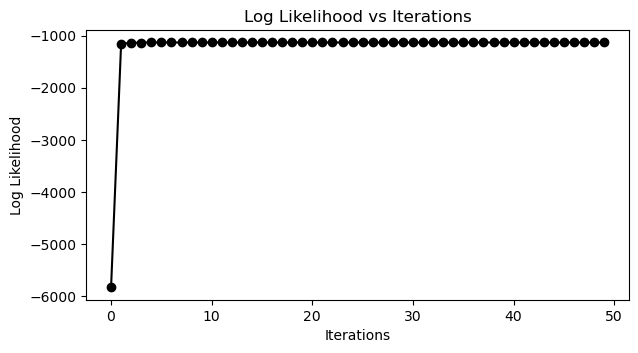

In [36]:
plt.figure(figsize=(7, 3.5))
plt.plot( epoch_log_likelihood.values(), marker='o', color='k')
plt.xlabel('Iterations')
plt.ylabel('Log Likelihood')
plt.title('Log Likelihood vs Iterations')
plt.show()

In [38]:
log_likelihood/N1

-11.676592141241178